# **SETUP AND DATA LOADING**
- Mount Google Drive and import all required libraries
- Load the plain-language comparison corpus (gov.uk pages) from CSV
- Load the privacy notices from individual .txt files in the `privacy policies` folder
- Stack both groups into a single DataFrame: `Domain`, `Title`, `Text`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, re, random
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt',                    quiet=True)
nltk.download('punkt_tab',               quiet=True)
nltk.download('stopwords',               quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

base_dir = '/content/drive/MyDrive/modelling_project'

In [3]:
#load the plain english group: gov.uk pages
plain = pd.read_csv(f'{base_dir}/gov_uk.csv', encoding='utf-8-sig', sep=';')
plain = plain.rename(columns={'title': 'Title', 'text': 'Text'})
plain['Title'] = plain['Title'].str.strip()   #trim stray newlines/spaces from titles
plain['Domain'] = 'plain'

#load the notice group: one .txt per company (.DS_Store skipped by endswith check)
notice_dir = f'{base_dir}/privacy policies'
rows = []
for filename in sorted(os.listdir(notice_dir)):
    if filename.endswith('.txt'):
        with open(os.path.join(notice_dir, filename), encoding='utf-8') as f:
            text = f.read()
        rows.append({
            'Domain': 'notice',
            'Title':  filename.replace('.txt', ''),
            'Source': filename.replace('.txt', ''),
            'Text':   text
        })
notices = pd.DataFrame(rows)

#combine both groups into one DataFrame
df = pd.concat(
    [plain[['Domain','Title','Text']], notices],
    ignore_index=True
)
print(df.groupby('Domain').size())
df[['Domain','Title']]

Domain
notice    10
plain     10
dtype: int64


,Domain,Title
0,plain,Data Protection: rights for data subjects
1,plain,Request copies of personal information held in...
2,plain,Personal information charter
3,plain,Privacy notice: how we use your data
4,plain,How to make a freedom of information (FOI) req...
5,plain,The UK's data protection legislation
6,plain,Find legal advice and information
7,plain,Data protection and your business
8,plain,Personal information charter HMRC
9,plain,Personal information charter DVLA


# **DATA CLEANING**
- The same cleaning function is applied to both groups for a fair comparison
- Strips: numbered/ALL-CAPS section headings, bullet markers, tab characters, extra blank lines
- Every cleaning choice is an interpretive choice: what is stripped is documented


In [4]:
def clean_text(text):
    text = text.replace('\r\n', '\n').replace('\r', '\n')    #normalise line endings
    text = text.replace('\f', ' ')                            #remove form-feed chars (PDF artefact)
    text = re.sub(r'^\s*\d+\.\s+[A-Z][^\n]{0,80}$', '', text, flags=re.MULTILINE)  #numbered headings
    text = re.sub(r'^[A-Z][A-Z\s&/]{5,}$',          '', text, flags=re.MULTILINE)  #ALL-CAPS headings
    text = re.sub(r'^\s*[•\-\–\—]\s*',              '', text, flags=re.MULTILINE)  #bullet markers
    text = re.sub(r'\t', ' ', text)                           #tabs to spaces

    #turn unpunctuated list lines into sentence units so readability formulas don't merge them
    lines = [ln.strip() for ln in text.split('\n') if ln.strip()]
    lines = [ln if ln[-1] in '.!?:;' else ln + '.' for ln in lines]
    text = ' '.join(lines)

    text = re.sub(r' {2,}', ' ', text)                        #collapse extra spaces
    return text.strip()

df['Text'] = df['Text'].apply(clean_text)

In [5]:
#word count per document after cleaning
df['words'] = df['Text'].str.split().str.len()
print(df[['Domain','Title','words']].sort_values('words').to_string())

    Domain                                                                                           Title  words
8    plain                                                               Personal information charter HMRC    360
5    plain                                                            The UK's data protection legislation    532
3    plain                                                            Privacy notice: how we use your data    745
4    plain                                              How to make a freedom of information (FOI) request    852
7    plain                                                               Data protection and your business    864
0    plain                                                       Data Protection: rights for data subjects    892
6    plain                                                               Find legal advice and information   1173
1    plain  Request copies of personal information held in the borders, immigration and 

In [6]:
#save the cleaned texts so we can inspect what the cleaning actually produced
cleaned_check = df[['Domain', 'Title', 'Text']].copy()
cleaned_check.to_csv(f'{base_dir}/cleaned_texts_check.csv', index=False, encoding='utf-8')
print(f'Saved {len(cleaned_check)} cleaned texts to cleaned_texts_check.csv')

#preview the first part of each cleaned text inline
for _, row in cleaned_check.iterrows():
    print(f'\n===== {row["Domain"].upper()} | {row["Title"]} =====')
    print(row['Text'][:500])   #first 500 characters

Saved 20 cleaned texts to cleaned_texts_check.csv

===== PLAIN | Data Protection: rights for data subjects =====
Under the Data Protection legislation, data subjects have the following rights with regards to their personal information: the right to be informed about the collection and the use of their personal data. the right to access personal data and supplementary information. the right to have inaccurate personal data rectified, or completed if it is incomplete. the right to erasure (to be forgotten) in certain circumstances. the right to restrict processing in certain circumstances. the right to data 

===== PLAIN | Request copies of personal information held in the borders, immigration and citizenship system =====
You have the right to access your personal information, known as a ‘Subject Access Request’ (SAR) or a ‘Right of Access Request’, under the Data Protection Act 2018. You can use this service to request personal information held on the Home Office’s immigration systems f

# **FEATURE EXTRACTION**
- All features are computed per document; domain means are used for comparison (measure each document on its own first, then collapse to two group averages to make the notice-vs-plain comparison)
- Numerical Benchmarks:
  - Flesch RE ≈ 60 (Flesch, R. (1949). The Art of Readable Writing. New York: Harper.)
  -  FK Grade ≈ 8 (Weiss, B.D. (2007), Health Literacy and Patient Safety: Help Patients Understand, American Medical Association Foundation )
  - avg sentence length ≤ 20 words (EU guide Hint 4)

**1. Readability (Flesch Reading Ease and Flesch-Kincaid Grade)**

- Flesch Reading Ease: higher score = easier (target ≈ 60 for public information)
- Flesch-Kincaid Grade: lower = easier (target ≈ grade 8 for public information)
- Limit: these formulas measure surface features only (word and sentence length); they cannot
  detect vague cross-references, nested conditions, or hedging, etc.

In [7]:
!pip install textstat -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 28.1 MB/s eta 0:00:00


In [8]:
import textstat

#compute readability scores per document
df['flesch_re'] = df['Text'].apply(textstat.flesch_reading_ease)
df['fk_grade']  = df['Text'].apply(textstat.flesch_kincaid_grade)

print('Mean readability by domain (Flesch RE target ≈ 60 | FK Grade target ≈ 8):')
print(df.groupby('Domain')[['flesch_re','fk_grade']].mean().round(2))

print('\nPer-document readability:')
print(df[['Domain','Title','flesch_re','fk_grade']].sort_values(['Domain','flesch_re']).to_string())

Mean readability by domain (Flesch RE target ≈ 60 | FK Grade target ≈ 8):
        flesch_re  fk_grade
Domain                     
notice      34.52     13.68
plain       50.61      9.65

Per-document readability:
    Domain                                                                                           Title  flesch_re   fk_grade
16  notice                                                                                         netflix  21.839411  17.226731
11  notice                                                                                          amazon  29.465888  14.918853
15  notice                                                                                       microsoft  30.324400  14.764666
10  notice                                                                                          airbnb  31.376378  13.620707
12  notice                                                                                           apple  32.363630  13.969024
18  notice   

**2. Average Sentence Length**
- EU *How to Write Clearly* Hint 4: aim for an average of 20 words per sentence
- Sentences tokenised with NLTK punkt; length = number of word tokens per sentence

In [9]:
from nltk.tokenize import sent_tokenize, word_tokenize

#sentences under 4 words are ignored: they are heading/table stubs (e.g. "Access." "Erasure."), as they aren't real sentences.
def avg_sentence_length(text, min_words=4):
    sentences = sent_tokenize(text)                          #split text into sentences
    lengths   = [len(word_tokenize(s)) for s in sentences]   #word count of each sentence
    lengths   = [l for l in lengths if l >= min_words]       #drop fragments under 4 words
    return round(sum(lengths) / len(lengths), 2) if lengths else 0

df['avg_sent_len'] = df['Text'].apply(avg_sentence_length)

print('Mean average sentence length by domain (EU guide target: 20 words):')
print(df.groupby('Domain')['avg_sent_len'].mean().round(2))

print('\nPer-document average sentence length:')
print(df[['Domain','Title','avg_sent_len']].sort_values('avg_sent_len').to_string())

Mean average sentence length by domain (EU guide target: 20 words):
Domain
notice    25.01
plain     16.03
Name: avg_sent_len, dtype: float64

Per-document average sentence length:
    Domain                                                                                           Title  avg_sent_len
5    plain                                                            The UK's data protection legislation         13.93
6    plain                                                               Find legal advice and information         14.03
8    plain                                                               Personal information charter HMRC         14.03
17  notice                                                                                         spotify         14.18
7    plain                                                               Data protection and your business         15.55
3    plain                                                            Privacy notice: how we 

**3. POS Distributions - Noun and Adjective Density (Nominalisation)**
- EU *How to Write Clearly* Hint 6: *Cut out excess nouns — verb forms are livelier*
- Noun density   = (NN + NNS + NNP + NNPS) / total tokens
- Adjective density = (JJ + JJR + JJS) / total tokens
- Verb density   = (VB + VBD + VBG + VBN + VBP + VBZ) / total tokens
- High noun density + low verb density is the signature of heavy nominalisation

In [10]:
from nltk import pos_tag, word_tokenize
import nltk

nltk.download('averaged_perceptron_tagger_eng', quiet=True)

#Penn Treebank tag groups
NOUN_TAGS = {'NN','NNS','NNP','NNPS'}
ADJ_TAGS  = {'JJ','JJR','JJS'}
VERB_TAGS = {'VB','VBD','VBG','VBN','VBP','VBZ'}

#share of nouns, adjectives, verbs out of all tokens (high noun + low verb = nominalisation)
def pos_densities(text):
    tokens = word_tokenize(text.lower())
    if not tokens:
        return 0, 0, 0
    tagged = pos_tag(tokens)
    total  = len(tokens)
    noun_d = round(sum(1 for _, t in tagged if t in NOUN_TAGS) / total, 4)
    adj_d  = round(sum(1 for _, t in tagged if t in ADJ_TAGS)  / total, 4)
    verb_d = round(sum(1 for _, t in tagged if t in VERB_TAGS) / total, 4)
    return noun_d, adj_d, verb_d

df[['noun_density','adj_density','verb_density']] = [
    pos_densities(text) for text in df['Text']
]

print('Mean POS densities by domain:')
print(df.groupby('Domain')[['noun_density','adj_density','verb_density']].mean().round(4))

print('\nPer-document POS densities:')
print(df[['Domain','Title','noun_density','adj_density','verb_density']].sort_values('noun_density', ascending=False).to_string())

Mean POS densities by domain:
        noun_density  adj_density  verb_density
Domain                                         
notice        0.2851        0.082        0.1318
plain         0.2572        0.077        0.1550

Per-document POS densities:
    Domain                                                                                           Title  noun_density  adj_density  verb_density
15  notice                                                                                       microsoft        0.3029       0.0896        0.1246
11  notice                                                                                          amazon        0.2958       0.0752        0.1223
16  notice                                                                                         netflix        0.2956       0.0964        0.1193
10  notice                                                                                          airbnb        0.2926       0.0969        0.1162
12  notic

**4. Passive Voice Rate**
- EU *How to Write Clearly* Hint 7: *Prefer active verbs to passive ones*
- Passive sentences detected via spaCy dependency labels: nsubjpass (passive subject) and auxpass (passive auxiliary)
- Rate = proportion of sentences containing at least one passive construction

In [11]:
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import spacy
nlp = spacy.load('en_core_web_sm')

PASSIVE_DEPS = {'nsubjpass', 'auxpass'}

def passive_rate(text):
    doc       = nlp(text)
    sentences = list(doc.sents)
    if not sentences:
        return 0
    passive_count = sum(
        1 for sent in sentences
        if any(tok.dep_ in PASSIVE_DEPS for tok in sent)
    )
    return round(passive_count / len(sentences), 4)

df['passive_rate'] = df['Text'].apply(passive_rate)

print('Mean passive voice rate by domain:')
print(df.groupby('Domain')['passive_rate'].mean().round(4))

print('\nPer-document passive rate:')
print(df[['Domain','Title','passive_rate']].sort_values('passive_rate').to_string())

Mean passive voice rate by domain:
Domain
notice    0.1212
plain     0.1387
Name: passive_rate, dtype: float64

Per-document passive rate:
    Domain                                                                                           Title  passive_rate
17  notice                                                                                         spotify        0.0442
6    plain                                                               Find legal advice and information        0.0495
8    plain                                                               Personal information charter HMRC        0.0667
18  notice                                                                                          tiktok        0.0740
11  notice                                                                                          amazon        0.0884
4    plain                                              How to make a freedom of information (FOI) request        0.1029
15  notice    

In [13]:
#the passive result runs opposite to the EU guide (plain shows MORE passive than notices).
#check if the highest-passive plain docs contain GENUINE passives

def show_passives(title, n=10):
    text = df[df['Title'] == title]['Text'].iloc[0]
    doc  = nlp(text)
    passives = [s.text.strip() for s in doc.sents if any(t.dep_ in PASSIVE_DEPS for t in s)]
    print(f'\n=== {title}: {len(passives)} passive sentences ===')
    for s in passives[:n]:
        print(' -', s[:130])

#the two highest-passive plain documents from the per-document table
show_passives('Privacy notice: how we use your data')
show_passives('Data Protection: rights for data subjects')


=== Privacy notice: how we use your data: 14 passive sentences ===
 - We use your data to check that you are allowed to access GOV.UK Notify and to record your activity when using it.
 - We will share your data if we are required to do so by law – for example, by court order, or to prevent fraud or other crime.
 - Where your data is processed and stored.
 - We design, build and run our systems to make sure that your data is as safe as possible at any stage, both while it’s processed an
 - Your personal data will be processed both in the UK and the European Economic Area (EEA).
 - Our services are not designed for, or intentionally targeted at, children 13 years of age or younger.
 - You have the right to request: information about how your personal data is processed.
 - a copy of that personal data – this copy will be provided in a structured, commonly used and machine-readable format.
 - that anything inaccurate in your personal data is corrected immediately.
 - You can also: raise a

**5. Formal Phrase Count**
- Two lists of formal phrases are counted and combined into a single rate: one taken directly from the EU guide, one drawing on broader plain-language sources
- Rate normalised per 1,000 words to allow comparison across documents of different lengths
- **EU list**: phrases taken directly from EU *How to Write Clearly* (EC, 2015), Hint 4, p. 6, which lists them as overly formal and gives plain alternatives
- **Extended list**: additional formal markers
- The two lists are kept separate in the code but reported as one combined rate

In [14]:
#EU phrases — taken directly from 'How to Write Clearly'
EU_FORMAL_PHRASES = [
    'in view of the fact that', 'a certain number of', 'the majority of',
    'pursuant to', 'within the framework of', 'accordingly', 'consequently',
    'for the purpose of', 'in the event of', 'if this is not the case',
    'if this is the case', 'concerning', 'regarding', 'relating to',
    'with reference to', 'with regard to'
]

#additional formal markers not from the EU guide
EXTRA_FORMAL_PHRASES = [
    'notwithstanding', 'hereinafter', 'aforementioned', 'inter alia',
    'with respect to', 'in respect of', 'in relation to', 'prior to',
    'subsequent to', 'in accordance with', 'by virtue of', 'in the context of',
    'on the basis of', 'by means of', 'in connection with', 'with a view to'
]

#rate per 1,000 words for a given phrase list
def phrase_rate(text, phrases):
    text_lower = text.lower()
    word_count = len(text_lower.split())
    count      = sum(text_lower.count(p) for p in phrases)
    return round((count / word_count) * 1000, 4) if word_count else 0

#compute both lists separately, then combine into one reported rate
df['eu_formal_rate']    = df['Text'].apply(lambda t: phrase_rate(t, EU_FORMAL_PHRASES))
df['extra_formal_rate'] = df['Text'].apply(lambda t: phrase_rate(t, EXTRA_FORMAL_PHRASES))
df['formal_rate']       = (df['eu_formal_rate'] + df['extra_formal_rate']).round(4)

print('Mean formal-phrase rate (per 1,000 words) by domain:')
print(df.groupby('Domain')['formal_rate'].mean().round(4))

print('\nPer-document formal-phrase rate:')
print(df[['Domain','Title','formal_rate']].sort_values('formal_rate', ascending=False).to_string())

Mean formal-phrase rate (per 1,000 words) by domain:
Domain
notice    2.0984
plain     1.4406
Name: formal_rate, dtype: float64

Per-document formal-phrase rate:
    Domain                                                                                           Title  formal_rate
0    plain                                                       Data Protection: rights for data subjects       6.7264
16  notice                                                                                         netflix       4.2214
5    plain                                                            The UK's data protection legislation       3.7594
10  notice                                                                                          airbnb       3.1886
11  notice                                                                                          amazon       2.9481
13  notice                                                                                         booking       2.551

**6. Modality - Deontic vs Epistemic**
- Deontic modals (*shall, must*): obligation - typical of regulatory and legal register
- Epistemic modals (*may, might, could, would*): possibility and hedging
- High deontic rate in a 'plain' document may signal legal obligation; high epistemic may signal vagueness
- Rate normalised per 1,000 words

In [15]:
DEONTIC   = {'shall', 'must'}                  #obligation
EPISTEMIC = {'may', 'might', 'could', 'would'}  #possibility / hedging

def modal_rates(text):
    tokens = text.lower().split()
    total  = len(tokens)
    if not total:
        return 0, 0
    deontic_r  = round(sum(1 for t in tokens if t in DEONTIC)   / total * 1000, 4)
    epistemic_r = round(sum(1 for t in tokens if t in EPISTEMIC) / total * 1000, 4)
    return deontic_r, epistemic_r

df[['deontic_rate','epistemic_rate']] = [modal_rates(t) for t in df['Text']]

print('Mean modal rates (per 1,000 words) by domain:')
print(df.groupby('Domain')[['deontic_rate','epistemic_rate']].mean().round(4))

print('\nPer-document modal rates:')
print(df[['Domain','Title','deontic_rate','epistemic_rate']].sort_values('deontic_rate', ascending=False).to_string())

Mean modal rates (per 1,000 words) by domain:
        deontic_rate  epistemic_rate
Domain                              
notice        0.3762          9.1048
plain         3.3694          6.4876

Per-document modal rates:
    Domain                                                                                           Title  deontic_rate  epistemic_rate
7    plain                                                               Data protection and your business       16.2037          6.9444
5    plain                                                            The UK's data protection legislation        5.6391          0.0000
1    plain  Request copies of personal information held in the borders, immigration and citizenship system        3.7258          3.7258
0    plain                                                       Data Protection: rights for data subjects        3.3632          4.4843
4    plain                                              How to make a freedom of information (

**7. Type-Token Ratio (TTR)**
- Measures vocabulary richness: unique word types / total tokens
- Computed on equal-length samples of 200 content words (stopwords removed) to control for document length as some of the texts in plain corpus are much shorter (pulls 200 words at random from anywhere in the document)
- Without equal-length sampling, longer documents would always score lower - the sampling corrects this.
- Higher TTR = more varied vocabulary; lower TTR = more repetition


In [16]:
from nltk.corpus import stopwords

random.seed(42)
stop_words = set(stopwords.words('english'))

def compute_ttr(text, n=200):
    tokens = [t.lower() for t in text.split() if t.isalpha() and t.lower() not in stop_words]
    if len(tokens) >= n:
        tokens = random.sample(tokens, n)  #sample to control for document length
    types = set(tokens)
    return round(len(types) / len(tokens), 3) if tokens else 0

df['ttr'] = df['Text'].apply(compute_ttr)

print('Mean TTR by domain (equal-length sample of 200 content words):')
print(df.groupby('Domain')['ttr'].mean().round(3))

print('\nPer-document TTR:')
print(df[['Domain','Title','ttr','words']].sort_values('ttr').to_string())

Mean TTR by domain (equal-length sample of 200 content words):
Domain
notice    0.709
plain     0.637
Name: ttr, dtype: float64

Per-document TTR:
    Domain                                                                                           Title    ttr  words
0    plain                                                       Data Protection: rights for data subjects  0.545    892
6    plain                                                               Find legal advice and information  0.565   1173
7    plain                                                               Data protection and your business  0.590    864
4    plain                                              How to make a freedom of information (FOI) request  0.605    852
12  notice                                                                                           apple  0.645   3866
8    plain                                                               Personal information charter HMRC  0.645    360
16  no

**8. Most Frequent Content Words**
- Top 20 nouns, verbs, and adjectives per domain (stopwords excluded)
- Reveals the thematic vocabulary and register differences between notices and plain texts

In [17]:
from collections import Counter

#pool all text per domain, then extract most frequent content words by POS
#runs on full corpus, not a sample - TTR tokens can't be reused here

for domain in ['notice', 'plain']:
    group_text = ' '.join(df[df['Domain'] == domain]['Text'])
    tokens     = word_tokenize(group_text.lower())
    tagged     = pos_tag(tokens)

    #filter by POS and remove stopwords - reuses tag sets defined in the POS cell
    nouns = [w for w, t in tagged if t in NOUN_TAGS and w.isalpha() and w not in stop_words]
    verbs = [w for w, t in tagged if t in VERB_TAGS and w.isalpha() and w not in stop_words]
    adjs  = [w for w, t in tagged if t in ADJ_TAGS  and w.isalpha() and w not in stop_words]

    print(f'\n--- {domain.upper()} ---')
    print(f'Top 20 nouns:  {[w for w,_ in Counter(nouns).most_common(20)]}')
    print(f'Top 20 verbs:  {[w for w,_ in Counter(verbs).most_common(20)]}')
    print(f'Top 20 adjs:   {[w for w,_ in Counter(adjs).most_common(20)]}')


--- NOTICE ---
Top 20 nouns:  ['information', 'data', 'services', 'account', 'privacy', 'service', 'content', 'device', 'platform', 'products', 'share', 'example', 'use', 'apple', 'access', 'law', 'settings', 'payment', 'partners', 'features']
Top 20 verbs:  ['use', 'provide', 'including', 'collect', 'using', 'make', 'see', 'include', 'receive', 'process', 'used', 'help', 'collected', 'protect', 'described', 'choose', 'improve', 'required', 'contact', 'disclose']
Top 20 adjs:   ['personal', 'third', 'certain', 'legal', 'netflix', 'microsoft', 'applicable', 'available', 'necessary', 'legitimate', 'additional', 'relevant', 'specific', 'similar', 'public', 'following', 'mobile', 'social', 'spotify', 'technical']

--- PLAIN ---
Top 20 nouns:  ['information', 'data', 'request', 'protection', 'right', 'example', 'processing', 'office', 'court', 'rights', 'organisation', 'access', 'law', 'home', 'staff', 'records', 'details', 'privacy', 'advice', 'circumstances']
Top 20 verbs:  ['ask', 'need

**9. Collocations (bigrams and trigrams)**
- ranked by PMI (Pointwise Mutual Information) - identifies word pairs/triples that co-occur more than chance
- Minimum frequency filter (apply_freq_filter) removes noise from low-count pairs
- Run separately on each group
- High-PMI collocations (frequent formulaic collocations) in notices are likely to reflect recurring legal formulas that privacy notices repeat across companies rather than writing afresh for the reader
- Connecting corpus analysis to the tradition of KWIC (Key Word In Context): collocations show *patterned* language, not just frequency

In [18]:
from nltk.collocations import BigramAssocMeasures,  BigramCollocationFinder
from nltk.collocations import TrigramAssocMeasures, TrigramCollocationFinder

bigram_measures  = BigramAssocMeasures()
trigram_measures = TrigramAssocMeasures()

for domain in ['notice', 'plain']:
    #pool all texts in this group into one token list, lowercased with stopwords removed
    group_text = ' '.join(df[df['Domain'] == domain]['Text'])
    tokens     = [t for t in group_text.lower().split() if t.isalpha() and t not in stop_words]

    #bigrams: ignore pairs appearing fewer than 5 times, then rank by PMI
    bi_finder = BigramCollocationFinder.from_words(tokens)
    bi_finder.apply_freq_filter(5)                          #ignore pairs appearing fewer than 5 times
    top_bigrams = bi_finder.nbest(bigram_measures.pmi, 15)

    #trigrams: lower frequency threshold (3) since three-word sequences are rarer
    tri_finder = TrigramCollocationFinder.from_words(tokens)
    tri_finder.apply_freq_filter(3)
    top_trigrams = tri_finder.nbest(trigram_measures.pmi, 15)

    print(f'\n--- {domain.upper()} ---')
    print(f'Top bigrams  (PMI): {top_bigrams}')
    print(f'Top trigrams (PMI): {top_trigrams}')


--- NOTICE ---
Top bigrams  (PMI): [('pixel', 'tags'), ('economic', 'area'), ('parent', 'guardian'), ('artificial', 'intelligence'), ('enter', 'enforceable'), ('united', 'kingdom'), ('partner', 'integrations'), ('enforcement', 'agencies'), ('state', 'residence'), ('european', 'economic'), ('european', 'union'), ('contractual', 'clauses'), ('survey', 'research'), ('enforceable', 'contract'), ('measure', 'effectiveness')]
Top trigrams (PMI): [('good', 'faith', 'belief'), ('machine', 'learning', 'models'), ('dpf', 'uk', 'extension'), ('european', 'economic', 'area'), ('enter', 'enforceable', 'contract'), ('matched', 'identifier', 'communications'), ('standard', 'contractual', 'clauses'), ('website', 'app', 'integrating'), ('digital', 'advertising', 'alliance'), ('country', 'state', 'residence'), ('european', 'union', 'united'), ('although', 'depends', 'specific'), ('enable', 'partner', 'integrations'), ('harm', 'property', 'safety'), ('collected', 'although', 'depends')]

--- PLAIN ---
T

# **VISUALISATION AND ANALYSIS**
- Per-document feature table summarising all extracted features
- Grouped bar charts compare notice vs plain group means on each feature
- Per-document readability chart (Flesch Reading Ease) showing the spread behind the group means, with the plain-language target (≈ 60) marked


In [19]:
#per-document summary table
feature_cols = [
    'Domain','Title','words',
    'flesch_re','fk_grade','avg_sent_len',
    'noun_density','adj_density','verb_density',
    'passive_rate','formal_rate',
    'deontic_rate','epistemic_rate','ttr'
]
feature_table = df[feature_cols].copy()
print(feature_table.to_string())

#save the per-document feature table to Drive
feature_table.to_csv(f'{base_dir}/corpus_features.csv', index=False, encoding='utf-8')
print('\nSaved to corpus_features.csv')

    Domain                                                                                           Title  words  flesch_re   fk_grade  avg_sent_len  noun_density  adj_density  verb_density  passive_rate  formal_rate  deontic_rate  epistemic_rate    ttr
0    plain                                                       Data Protection: rights for data subjects    892  44.264392  10.778628         16.53        0.2429       0.0837        0.1704        0.2542       6.7264        3.3632          4.4843  0.545
1    plain  Request copies of personal information held in the borders, immigration and citizenship system   1342  52.229351   9.670436         16.71        0.2484       0.0646        0.1601        0.1275       0.7452        3.7258          3.7258  0.680
2    plain                                                                    Personal information charter   1940  45.775924  10.776640         18.02        0.2487       0.0775        0.1586        0.1250       2.0619        0.5155    

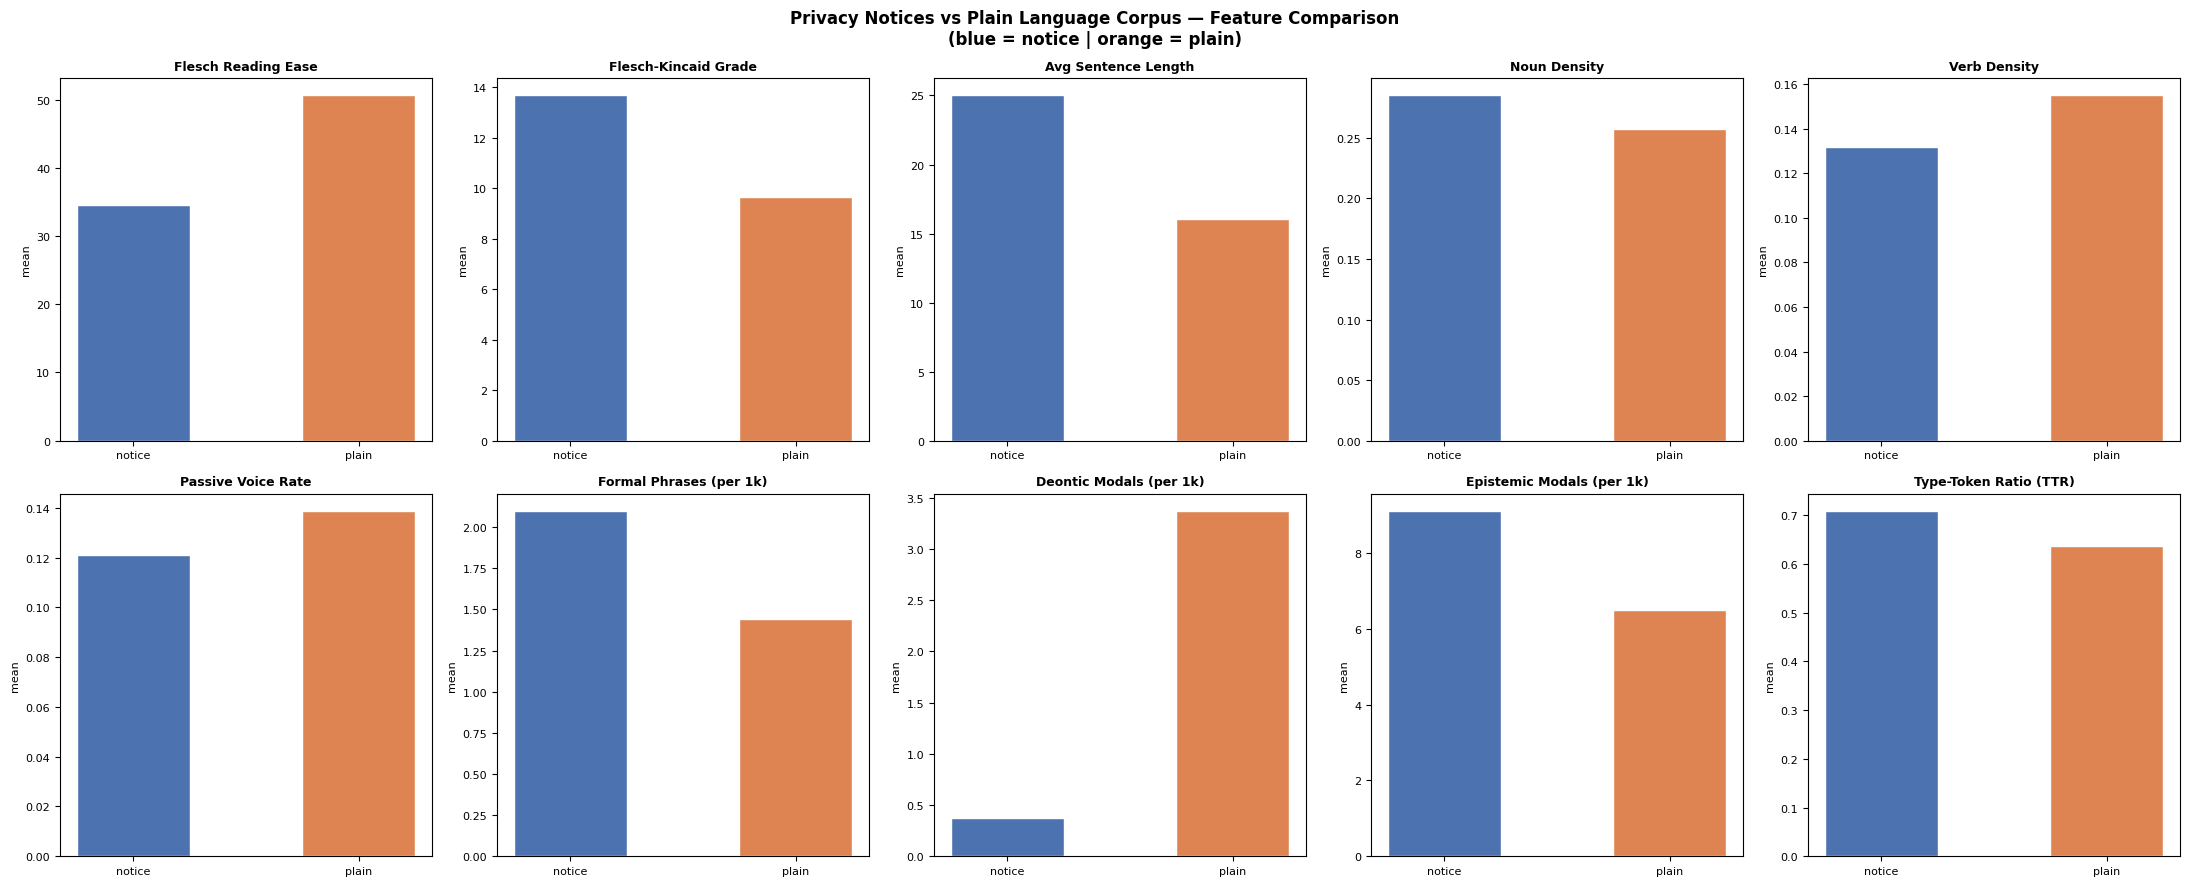

Chart saved to Drive.


In [20]:
#features to plot: (column, label)
PLOT_FEATURES = [
    ('flesch_re',      'Flesch Reading Ease'),
    ('fk_grade',       'Flesch-Kincaid Grade'),
    ('avg_sent_len',   'Avg Sentence Length'),
    ('noun_density',   'Noun Density'),
    ('verb_density',   'Verb Density'),
    ('passive_rate',   'Passive Voice Rate'),
    ('formal_rate',    'Formal Phrases (per 1k)'),
    ('deontic_rate',   'Deontic Modals (per 1k)'),
    ('epistemic_rate', 'Epistemic Modals (per 1k)'),
    ('ttr',            'Type-Token Ratio (TTR)'),
]

means = df.groupby('Domain')[[f for f,_ in PLOT_FEATURES]].mean()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, (feature, label) in enumerate(PLOT_FEATURES):
    ax      = axes[idx]
    domains = means.index.tolist()
    values  = means[feature].tolist()
    colors  = ['#4C72B0', '#DD8452']   #notice = blue, plain = orange

    ax.bar(domains, values, color=colors, width=0.5, edgecolor='white')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel('mean', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(
    'Privacy Notices vs Plain Language Corpus — Feature Comparison\n'
    '(blue = notice | orange = plain)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{base_dir}/feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to Drive.')

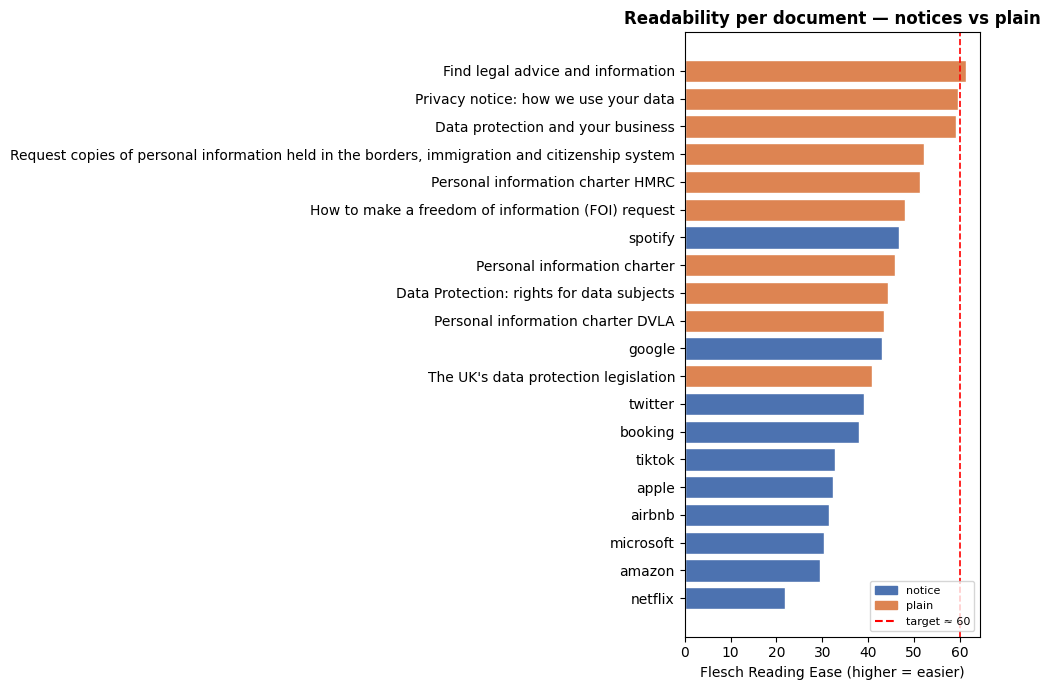

Chart saved to Drive.


In [21]:
#per-document Flesch Reading Ease, coloured by group, to show spread behind the group means
plot_df = df.sort_values('flesch_re')
colors  = ['#4C72B0' if d == 'notice' else '#DD8452' for d in plot_df['Domain']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['Title'], plot_df['flesch_re'], color=colors, edgecolor='white')

ax.axvline(60, color='red', linestyle='--', linewidth=1.2, label='plain-language target ≈ 60')
ax.set_xlabel('Flesch Reading Ease (higher = easier)')
ax.set_title('Readability per document — notices vs plain', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

#manual legend for the two groups
from matplotlib.patches import Patch
group_handles = [Patch(color='#4C72B0', label='notice'), Patch(color='#DD8452', label='plain')]
ax.legend(handles=group_handles + [plt.Line2D([0],[0], color='red', linestyle='--', label='target ≈ 60')], fontsize=8)

plt.tight_layout()
plt.savefig(f'{base_dir}/readability_per_document.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to Drive.')

# **CLOSE READING — KWIC CONCORDANCES**
- KWIC (Key Word In Context): each occurrence of a target phrase shown with surrounding context
- Target phrases: typical privacy-notice formulas (*we may collect*, *third parties*, *in accordance with*)
- Frequency counts alone do not show how a phrase is used; concordances enable qualitative close reading

In [22]:
def kwic(text, keyword, window=7):
    tokens         = text.lower().split()
    keyword_tokens = keyword.lower().split()
    k_len          = len(keyword_tokens)
    results        = []
    for i in range(len(tokens) - k_len + 1):
        if tokens[i:i+k_len] == keyword_tokens:
            left  = ' '.join(tokens[max(0, i-window):i])
            right = ' '.join(tokens[i+k_len:i+k_len+window])
            results.append(f'{left:45s}  [{keyword}]  {right}')
    return results

notice_text = ' '.join(df[df['Domain'] == 'notice']['Text'])
plain_text  = ' '.join(df[df['Domain'] == 'plain']['Text'])

target_phrases = ['we may collect', 'third parties', 'in accordance with', 'personal data', 'your information']

for phrase in target_phrases:
    hits_n = kwic(notice_text, phrase)
    hits_p = kwic(plain_text,  phrase)
    print(f'\n=== "{phrase}" === notices: {len(hits_n)} | plain: {len(hits_p)}')
    print('  -- first 5 from notices --')
    for line in hits_n[:5]:
        print(f'  {line}')


=== "we may collect" === notices: 20 | plain: 0
  -- first 5 from notices --
  insurance information. if you are a host,      [we may collect]  information regarding your business, commercial, or professional
  license information. if you are a host,        [we may collect]  information such as business, commercial, or professional
  of one of our airbnb community networks,       [we may collect]  information such as your profile, your user-generated
  and links you click to third-party applications.  [we may collect]  this information even if you haven’t created
  unique identifiers, crash data, and read receipts.  [we may collect]  this information even if you haven’t created

=== "third parties" === notices: 53 | plain: 5
  -- first 5 from notices --
  information is used to enable, or authorize    [third parties]  to use, payment services (as defined in
  we may also disclose this information to       [third parties]  engaged by the enterprise to provide support
  third parties. w

# **SAVE COMBINED CORPUS**
- Save the cleaned + annotated DataFrame (all features) back to Drive

In [23]:
df.to_csv(f'{base_dir}/corpus_combined.csv', index=False, encoding='utf-8')
print(f'Saved {len(df)} rows to corpus_combined.csv')
print(df.groupby('Domain').size())

Saved 20 rows to corpus_combined.csv
Domain
notice    10
plain     10
dtype: int64
